Librerías usadas

In [34]:


from kagglehub import dataset_download
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix



funcion para repartir los datos de entrenamiento en varios  arrays

In [35]:
import numpy as np

def split_dataset(X, y, n_splits=2, shuffle=True, random_state=42):
    """
    Divide X e y en n_splits partes.

    Retorna:
        lista de tuplas: [(X_part1, y_part1), (X_part2, y_part2), ...]
    """
    if n_splits < 2:
        raise ValueError("n_splits debe ser >= 2")
    if len(X) != len(y):
        raise ValueError("X e y deben tener la misma cantidad de filas")

    n = len(X)
    indices = np.arange(n)

    if shuffle:
        rng = np.random.default_rng(random_state)
        rng.shuffle(indices)

    # Índices divididos en partes (lo más balanceadas posible)
    split_indices = np.array_split(indices, n_splits)

    # Construir salida
    parts = []
    for idx in split_indices:
        parts.append((X[idx], y[idx]))
    return parts

1. CARGA Y PREPARACIÓN DE DATOS

In [36]:
print("Descargando dataset...")
path = dataset_download("oddrationale/mnist-in-csv")

train_df = pd.read_csv(path + "/mnist_train.csv")
test_df = pd.read_csv(path + "/mnist_test.csv")

print(train_df.shape)
print(train_df)
train_df.head()

# Separar características (X) y etiquetas (y)
X_train = train_df.iloc[:, 1:].values  # 60000 imágenes de 784 píxeles (28x28)
y_train = train_df.iloc[:, 0].values   # 60000 etiquetas (0-9)
X_test = test_df.iloc[:, 1:].values
y_test = test_df.iloc[:, 0].values

# Normalizar: los píxeles van de 0-255, los llevamos a 0-1
# Esto ayuda a que los gradientes no exploten y el entrenamiento sea estable
X_train = X_train / 255.0
X_test = X_test / 255.0

print(f"X_train shape: {X_train.shape}")  # (60000, 784)
print(f"y_train shape: {y_train.shape}")  # (60000,)
print(f"X_test shape: {X_test.shape}")     # (10000, 784)
print(f"y_test shape: {y_test.shape}")     # (10000,)

Descargando dataset...
(60000, 785)
       label  1x1  1x2  1x3  1x4  1x5  1x6  1x7  1x8  1x9  ...  28x19  28x20  \
0          5    0    0    0    0    0    0    0    0    0  ...      0      0   
1          0    0    0    0    0    0    0    0    0    0  ...      0      0   
2          4    0    0    0    0    0    0    0    0    0  ...      0      0   
3          1    0    0    0    0    0    0    0    0    0  ...      0      0   
4          9    0    0    0    0    0    0    0    0    0  ...      0      0   
...      ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...    ...    ...   
59995      8    0    0    0    0    0    0    0    0    0  ...      0      0   
59996      3    0    0    0    0    0    0    0    0    0  ...      0      0   
59997      5    0    0    0    0    0    0    0    0    0  ...      0      0   
59998      6    0    0    0    0    0    0    0    0    0  ...      0      0   
59999      8    0    0    0    0    0    0    0    0    0  ...      0      0   

   

2. ARQUITECTURA DE LA RED NEURONAL

In [37]:


# Capa de entrada: 784 neuronas (28x28 píxeles)
# Capa oculta 1: 128 neuronas
# Capa oculta 2: 64 neuronas
# Capa de salida: 10 neuronas (uno por cada dígito 0-9)

# Hiperparámetros
INPUT_SIZE = 784      # 28 * 28
HIDDEN_SIZE = 10    # Primera capa oculta
OUTPUT_SIZE = 10      # Dígitos 0-9
LEARNING_RATE = 0.05  # Qué tan grandes son los pasos del gradiente
EPOCHS = 500           # Cuántas veces ve todo el dataset



3. INICIALIZACIÓN DE PESOS Y SESGOS

In [38]:

def initialize_parameters(input_size, hiden_size, output_size):
    # Capa 1: Entrada (784) → Oculta (HIDDEN_SIZE)
    # Cada fila corresponde a una entrada, cada columna a una neurona de la capa ocult
    w1 = np.random.randn(INPUT_SIZE, HIDDEN_SIZE) * 0.01
    b1 = np.zeros((1, HIDDEN_SIZE))
    w2 = np.random.randn(HIDDEN_SIZE, OUTPUT_SIZE) * 0.01
    b2 = np.zeros((1, OUTPUT_SIZE))

    # Copias (no referencias)
    params_part1 = {"w1": w1.copy(), "b1": b1.copy(), "w2": w2.copy(), "b2": b2.copy()}
    params_part2 = {"w1": w1.copy(), "b1": b1.copy(), "w2": w2.copy(), "b2": b2.copy()}

    return params_part1, params_part2

def print_parameters():
    params_part1, params_part2 = initialize_parameters(784,10,10)

    print(f"Pesos w1 de la primera division: {params_part1['w1'].shape}, b1: {params_part1['b1'].shape}")
    print(f"Pesos w2 de la primera division: {params_part1['w2'].shape}, b2: {params_part1['b2'].shape}")
    print(f"Pesos w1 de la segunda division: {params_part2['w1'].shape}, b1: {params_part2['b1'].shape}")
    print(f"Pesos w2 de la segunda division: {params_part2['w2'].shape}, b2: {params_part2['b2'].shape}")

    print(f"Primeros 5 pesos w1 de la primera division:\n{params_part1['w1'][:5]}")
    print(f"Primeros 5 pesos w1 de la segunda division:\n{params_part2['w1'][:5]}")
    print(f"Primeros 5 pesos w2 de la primera division:\n{params_part1['w2'][:5]}")
    print(f"Primeros 5 pesos w2 de la segunda division:\n{params_part2['w2'][:5]}")

print_parameters()

Pesos w1 de la primera division: (784, 10), b1: (1, 10)
Pesos w2 de la primera division: (10, 10), b2: (1, 10)
Pesos w1 de la segunda division: (784, 10), b1: (1, 10)
Pesos w2 de la segunda division: (10, 10), b2: (1, 10)
Primeros 5 pesos w1 de la primera division:
[[ 0.00426816  0.004927   -0.00395779  0.00138488 -0.00943013 -0.01240579
  -0.01126446  0.00181356 -0.00401096  0.00609182]
 [-0.00032447 -0.00896721  0.00103279  0.00572709  0.00593815  0.01187335
  -0.02136877  0.01126804 -0.00963297  0.00952676]
 [ 0.00016077  0.00670082  0.00578094  0.01399693 -0.00311819 -0.00753183
   0.02049446  0.0088013  -0.00577786  0.01574489]
 [ 0.00489024  0.01087794  0.00657988  0.00738322 -0.00990181  0.01249429
  -0.0162509  -0.01429452  0.00655445  0.00398101]
 [-0.00423645  0.01793818 -0.00064345  0.01076255  0.00386714 -0.01750299
   0.00588242 -0.00514814  0.01022872 -0.00938733]]
Primeros 5 pesos w1 de la segunda division:
[[ 0.00426816  0.004927   -0.00395779  0.00138488 -0.00943013 -0

4. FUNCIONES DE ACTIVACIÓN

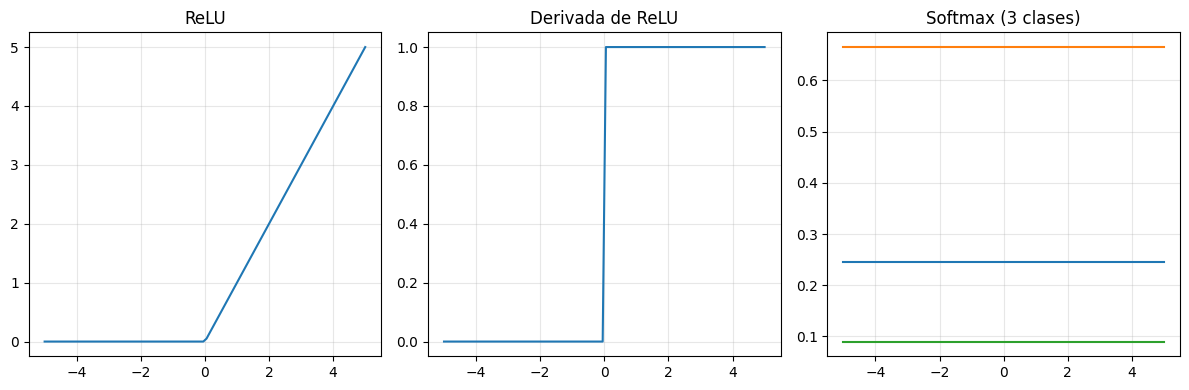

In [39]:
def relu(z):
    """
    Rectified Linear Unit: max(0, z)
    Si z > 0, devuelve z. Si z <= 0, devuelve 0.
    Es no lineal, simple y evita el problema del gradiente desvaneciente.
    """
    return np.maximum(0, z)

def relu_derivative(z):
    """
    Derivada de ReLU: 1 si z > 0, 0 si z <= 0
    Esto se usa en backpropagation para calcular gradientes.
    """
    return (z > 0).astype(float)

def softmax(z):
    """
    Softmax: convierte logits en probabilidades que suman 1.
    z puede ser cualquier número, softmax lo normaliza.
    Se resta el max para estabilidad numérica (evita overflow).
    """
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# Imprimir ejemplos de activaciones, plot
x_samples = np.linspace(-5, 5, 100)
relu_samples = relu(x_samples)
relu_deriv_samples = relu_derivative(x_samples)
softmax_samples = softmax(np.array([x_samples, x_samples + 1, x_samples - 1]).T)  # 3 clases
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(x_samples, relu_samples)
plt.title("ReLU")
plt.grid(True, alpha=0.3)
plt.subplot(1, 3, 2)
plt.plot(x_samples, relu_deriv_samples)
plt.title("Derivada de ReLU")
plt.grid(True, alpha=0.3)
plt.subplot(1, 3, 3)
plt.plot(x_samples, softmax_samples)
plt.title("Softmax (3 clases)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

5. FUNCIÓN DE COSTO (ERROR CUADRÁTICO MEDIO)

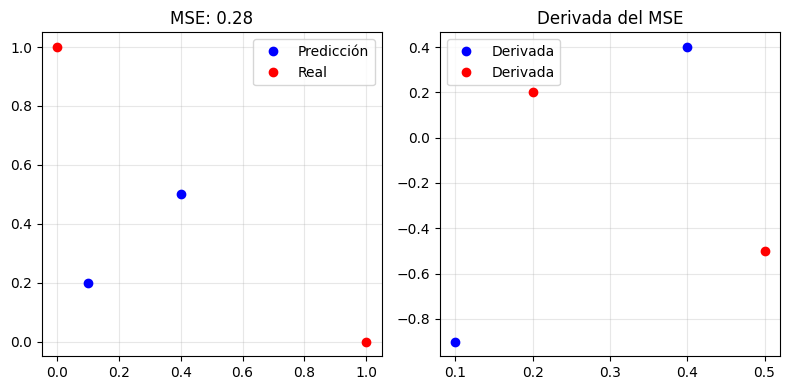

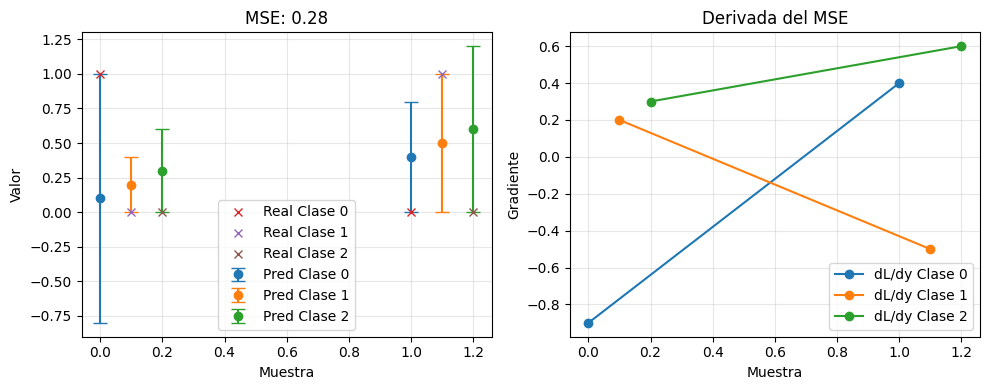

In [40]:


def mse_loss(y_pred, y_true_one_hot):
    """
    Error Cuadrático Medio: MSE = (1/n) * Σ(y_pred - y_true)²
    Mide qué tan lejos están las predicciones de los valores reales.
    """
    return np.mean((y_pred - y_true_one_hot) ** 2)

def mse_derivative(y_pred, y_true_one_hot):
    """
    Derivada del MSE respecto a y_pred: 2*(y_pred - y_true)/n
    Esto nos dice en qué dirección ajustar para reducir el error.
    """
    n = y_pred.shape[0]
    return 2 * (y_pred - y_true_one_hot) / n

# Ejemplo de datos para mse y su derivada
y_pred = np.array([[0.1, 0.2, 0.3], [0.4, 0.5, 0.6]])
y_true_one_hot = np.array([[1, 0, 0], [0, 1, 0]])

mse = mse_loss(y_pred, y_true_one_hot)
mse_deriv = mse_derivative(y_pred, y_true_one_hot)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.plot(y_pred[:, 0], y_pred[:, 1], 'bo', label='Predicción')
plt.plot(y_true_one_hot[:, 0], y_true_one_hot[:, 1], 'ro', label='Real')
plt.title("MSE: {:.2f}".format(mse))
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(y_pred[:, 0], mse_deriv[:, 0], 'bo', label='Derivada')
plt.plot(y_pred[:, 1], mse_deriv[:, 1], 'ro', label='Derivada')
plt.title("Derivada del MSE")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


########################################################
mse = mse_loss(y_pred, y_true_one_hot)
mse_deriv = mse_derivative(y_pred, y_true_one_hot)

# ===========================================
# Gráfica con barras de error
# ===========================================
plt.figure(figsize=(10, 4))

# Subplot 1: Predicciones vs reales con barras de error
plt.subplot(1, 2, 1)
x = np.arange(y_pred.shape[0])  # índice de cada muestra
for i in range(y_pred.shape[1]):  # cada clase
    plt.errorbar(x + i*0.1, y_pred[:, i],
                 yerr=np.abs(y_pred[:, i] - y_true_one_hot[:, i]),
                 fmt='o', capsize=5, label=f'Pred Clase {i}')

# Puntos reales
for i in range(y_true_one_hot.shape[1]):
    plt.plot(x + i*0.1, y_true_one_hot[:, i], 'x', label=f'Real Clase {i}')

plt.title(f"MSE: {mse:.2f}")
plt.xlabel("Muestra")
plt.ylabel("Valor")
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Derivada del MSE
plt.subplot(1, 2, 2)
for i in range(y_pred.shape[1]):
    plt.plot(x + i*0.1, mse_deriv[:, i], 'o-', label=f'dL/dy Clase {i}')

plt.title("Derivada del MSE")
plt.xlabel("Muestra")
plt.ylabel("Gradiente")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



6. ONE-HOT ENCODING, etiquetar Y

In [9]:


def one_hot(y, num_classes=10):
    """
    Convierte etiquetas [0, 5, 3, ...] en vectores one-hot:
    0 -> [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    5 -> [0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
    Necesario para comparar con la salida de softmax (10 probabilidades).
    """
    one_hot_matrix = np.zeros((len(y), num_classes))
    one_hot_matrix[np.arange(len(y)), y] = 1
    return one_hot_matrix

# ejemplo de uso
y_example = y_train[:5]  # primeras 5 etiquetas
y_one_hot_example = one_hot(y_example)
print("Etiquetas originales:", y_example)
print("One-hot encoded:\n", y_one_hot_example)



Etiquetas originales: [5 0 4 1 9]
One-hot encoded:
 [[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]



7. FORWARD PROPAGATION (PASO HACIA ADELANTE)

In [41]:
def forward(X, params):
    """
    Calcula la salida de la red paso a paso para un conjunto de parámetros.

    X: matriz de entrada (batch_size, 784)
    params: diccionario con w1, b1, w2, b2
    """
    w1, b1 = params['w1'], params['b1']
    w2, b2 = params['w2'], params['b2']

    # Capa 1: Entrada -> Oculta
    z1 = np.dot(X, w1) + b1
    a1 = relu(z1)

    # Capa 2: Oculta -> Salida
    z2 = np.dot(a1, w2) + b2
    a2 = softmax(z2)

    cache = {
        'X': X,
        'z1': z1, 'a1': a1,
        'z2': z2, 'a2': a2
    }

    return a2, cache

8. BACKWARD PROPAGATION (PASO HACIA ATRÁS)

In [42]:
def backward(cache, y_true_one_hot, params):
    """
    Calcula gradientes y actualiza parámetros para una partición específica.
    """
    X = cache['X']
    a1, z1 = cache['a1'], cache['z1']
    a2 = cache['a2']

    w2 = params['w2']

    # Gradientes capa de salida
    dz2 = mse_derivative(a2, y_true_one_hot)
    dw2 = np.dot(a1.T, dz2)
    db2 = np.sum(dz2, axis=0, keepdims=True)

    # Gradientes capa oculta
    dz1 = np.dot(dz2, w2.T) * relu_derivative(z1)
    dw1 = np.dot(X.T, dz1)
    db1 = np.sum(dz1, axis=0, keepdims=True)

    # Actualización
    params['w2'] -= LEARNING_RATE * dw2
    params['b2'] -= LEARNING_RATE * db2
    params['w1'] -= LEARNING_RATE * dw1
    params['b1'] -= LEARNING_RATE * db1

    return dw1, dw2

9. ENTRENAMIENTO (GRADIENT DESCENT NO ESTOCÁSTICO)

In [43]:
def train_batch(X_batch, y_batch, params):
    """
    Entrena una partición con Batch Gradient Descent.
    """
    output, cache = forward(X_batch, params)
    y_one_hot = one_hot(y_batch)
    loss = mse_loss(output, y_one_hot)
    backward(cache, y_one_hot, params)

    predictions = np.argmax(output, axis=1)
    accuracy = np.mean(predictions == y_batch)
    return loss, accuracy

def predict_proba(X, params):
    output, _ = forward(X, params)
    return output

def predict(X, params):
    return np.argmax(predict_proba(X, params), axis=1)


10. BUCLE DE ENTRENAMIENTO

In [47]:
# Configuración de repeticiones para análisis estadístico
import kagglehub


def mse_loss(y_pred, y_true):
    """Error cuadrático medio (MSE). Soporta etiquetas enteras y one-hot."""
    if y_true.ndim == 1:
        y_true = np.eye(y_pred.shape[1])[y_true]
    return np.mean((y_pred - y_true) ** 2)


def copiar_parametros(params):
    """Copia profunda de parámetros (dict de arrays numpy)."""
    return {k: v.copy() for k, v in params.items()}


N_REPETICIONES = 1  # Para pruebas rápidas, se puede aumentar a 50 o más para análisis estadístico completo

print("\n" + "="*50)
print(f"INICIANDO ENTRENAMIENTO ({N_REPETICIONES} REPETICIONES)")
print("="*50)
print(f"Épocas por repetición: {EPOCHS}")
print(f"Learning Rate: {LEARNING_RATE}")
print(f"Muestras de entrenamiento: {len(X_train)}")
print(f"Repeticiones: {N_REPETICIONES}")
print("="*50)

# Listas para almacenar resultados de cada repetición (compatibles con celdas siguientes)
resultados_train_acc = []
resultados_test_acc = []

# Lista de registros por iteración para análisis/exportación
resultados_iteraciones = []

# Dividir el dataset en dos partes (se mantiene igual para todas las repeticiones)
parts = split_dataset(X_train, y_train, n_splits=2, shuffle=True, random_state=42)
(X_train_part1, y_train_part1), (X_train_part2, y_train_part2) = parts

print(f"Partición 1: {X_train_part1.shape}, etiquetas: {y_train_part1.shape}")
print(f"Partición 2: {X_train_part2.shape}, etiquetas: {y_train_part2.shape}")

# BUCLE DE REPETICIONES
for repeticion in range(N_REPETICIONES):
    # Reinicializar parámetros para cada repetición
    params_part1, params_part2 = initialize_parameters(INPUT_SIZE, HIDDEN_SIZE, OUTPUT_SIZE)
    params_global = copiar_parametros(params_part1)

    # Entrenar durante EPOCHS iteraciones
    for epoch in range(EPOCHS):
        # Sincronizar ambos para la próxima iteración
        params_part1 = copiar_parametros(params_global)
        params_part2 = copiar_parametros(params_global)

        loss1, acc1 = train_batch(X_train_part1, y_train_part1, params_part1)
        loss2, acc2 = train_batch(X_train_part2, y_train_part2, params_part2)

        params_global['w1'] = (params_part1['w1'] + params_part2['w1']) / 2
        params_global['b1'] = (params_part1['b1'] + params_part2['b1']) / 2
        params_global['w2'] = (params_part1['w2'] + params_part2['w2']) / 2
        params_global['b2'] = (params_part1['b2'] + params_part2['b2']) / 2

    # Evaluar modelo
    train_preds_final = predict(X_train, params_global)
    test_preds_final = predict(X_test, params_global)
    train_acc_final = np.mean(train_preds_final == y_train)
    test_acc_final = np.mean(test_preds_final == y_test)

    # Guardar resultados (listas existentes)
    resultados_train_acc.append(train_acc_final)
    resultados_test_acc.append(test_acc_final)

    # Guardar resultados detallados por iteración
    resultados_iteraciones.append({
        'iteracion': repeticion + 1,
        'train_acc_final': train_acc_final,
        'test_acc_final': test_acc_final,
    })

    if (repeticion + 1) % 10 == 0 or repeticion == 0:
        print(
            f"Repetición {repeticion+1:2d}/{N_REPETICIONES} | "
            f"Train Acc (final): {train_acc_final:.4f} | "
            f"Test Acc (final): {test_acc_final:.4f}"
        )

# Guardar params finales para uso posterior (visualización/guardado de modelo)
params_final = copiar_parametros(params_global)

# DataFrame con resultados de todas las iteraciones
df_resultados = pd.DataFrame(resultados_iteraciones)

print("\n" + "="*50)
print("ENTRENAMIENTO COMPLETADO")
print("="*50)
print("\nPrimeras filas de resultados por iteración:")
print(df_resultados.head())


INICIANDO ENTRENAMIENTO (1 REPETICIONES)
Épocas por repetición: 500
Learning Rate: 0.05
Muestras de entrenamiento: 60000
Repeticiones: 1
Partición 1: (30000, 784), etiquetas: (30000,)
Partición 2: (30000, 784), etiquetas: (30000,)
Repetición  1/1 | Train Acc (final): 0.8875 | Test Acc (final): 0.8911

ENTRENAMIENTO COMPLETADO

Primeras filas de resultados por iteración:
   iteracion  train_acc_final  test_acc_final
0          1         0.887517          0.8911


In [48]:
# Guardar resultados detallados por iteración en CSV
ruta_csv_resultados = "resultados_entrenamiento_50_repeticiones.csv"
df_resultados.to_csv(ruta_csv_resultados, index=False)
print(f"\nResultados guardados en: {ruta_csv_resultados}")


Resultados guardados en: resultados_entrenamiento_50_repeticiones.csv


11. VISUALIZACIÓN DE RESULTADOS


Ejemplos de predicciones del modelo final promediado:


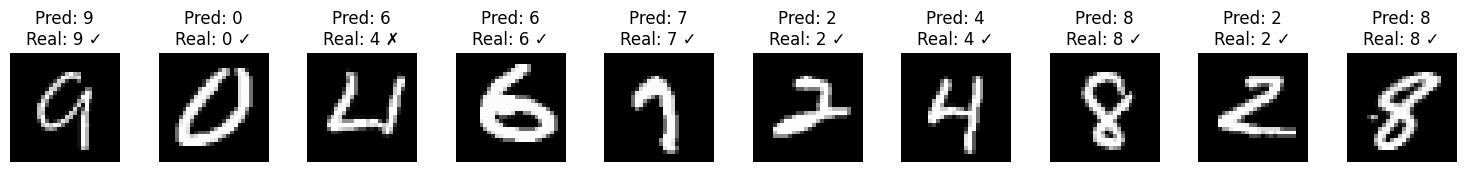

In [49]:
# Mostrar ejemplos de predicciones del modelo final promediado de la última repetición
print("\nEjemplos de predicciones del modelo final promediado:")

plt.figure(figsize=(15, 3))
sample_indices = np.random.choice(len(X_test), 10, replace=False)
predictions = predict(X_test[sample_indices], params_final)

for i, idx in enumerate(sample_indices):
    plt.subplot(2, 10, i+1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    correcto = '✓' if predictions[i] == y_test[idx] else '✗'
    plt.title(f"Pred: {predictions[i]}\nReal: {y_test[idx]} {correcto}")
    plt.axis('off')

plt.tight_layout()
plt.show()

12. EVALUACIÓN FINAL

In [50]:
print("\n" + "="*50)
print("ANÁLISIS ESTADÍSTICO (50 REPETICIONES)")
print("="*50)

# Convertir a arrays numpy para cálculos estadísticos
train_acc_arr = np.array(resultados_train_acc)
test_acc_arr = np.array(resultados_test_acc)
part1_acc_arr = np.array(resultados_train_acc_part1)
part2_acc_arr = np.array(resultados_train_acc_part2)

# Estadísticas descriptivas
print("\n--- MODELO PROMEDIADO EN TEST SET ---")
print(f"Media:              {np.mean(test_acc_arr):.4f}")
print(f"Desv. Estándar:       {np.std(test_acc_arr):.4f}")
print(f"Mínimo:             {np.min(test_acc_arr):.4f}")
print(f"Máximo:             {np.max(test_acc_arr):.4f}")
print(f"Mediana:            {np.median(test_acc_arr):.4f}")
print(f"Q1 (25%):           {np.percentile(test_acc_arr, 25):.4f}")
print(f"Q3 (75%):           {np.percentile(test_acc_arr, 75):.4f}")

print("\n--- MODELO PROMEDIADO EN ENTRENAMIENTO ---")
print(f"Media:              {np.mean(train_acc_arr):.4f}")
print(f"Desv. Estándar:       {np.std(train_acc_arr):.4f}")
print(f"Mínimo:             {np.min(train_acc_arr):.4f}")
print(f"Máximo:             {np.max(train_acc_arr):.4f}")

print("\n--- PARTICIONES INDIVIDUALES EN ENTRENAMIENTO ---")
print(f"Part1 Media:        {np.mean(part1_acc_arr):.4f} ± {np.std(part1_acc_arr):.4f}")
print(f"Part2 Media:        {np.mean(part2_acc_arr):.4f} ± {np.std(part2_acc_arr):.4f}")

print("\n" + "="*50)


ANÁLISIS ESTADÍSTICO (50 REPETICIONES)

--- MODELO PROMEDIADO EN TEST SET ---
Media:              0.8911
Desv. Estándar:       0.0000
Mínimo:             0.8911
Máximo:             0.8911
Mediana:            0.8911
Q1 (25%):           0.8911
Q3 (75%):           0.8911

--- MODELO PROMEDIADO EN ENTRENAMIENTO ---
Media:              0.8875
Desv. Estándar:       0.0000
Mínimo:             0.8875
Máximo:             0.8875

--- PARTICIONES INDIVIDUALES EN ENTRENAMIENTO ---
Part1 Media:        0.8954 ± 0.0000
Part2 Media:        0.8964 ± 0.0000



14. VISUALIZACIÓN DE RESULTADOS ESTADÍSTICOS (50 REPETICIONES)

/tmp/ipykernel_4328/1026603866.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot(box_data, labels=['Test (Final)', 'Train (Final)', 'Part1', 'Part2'])


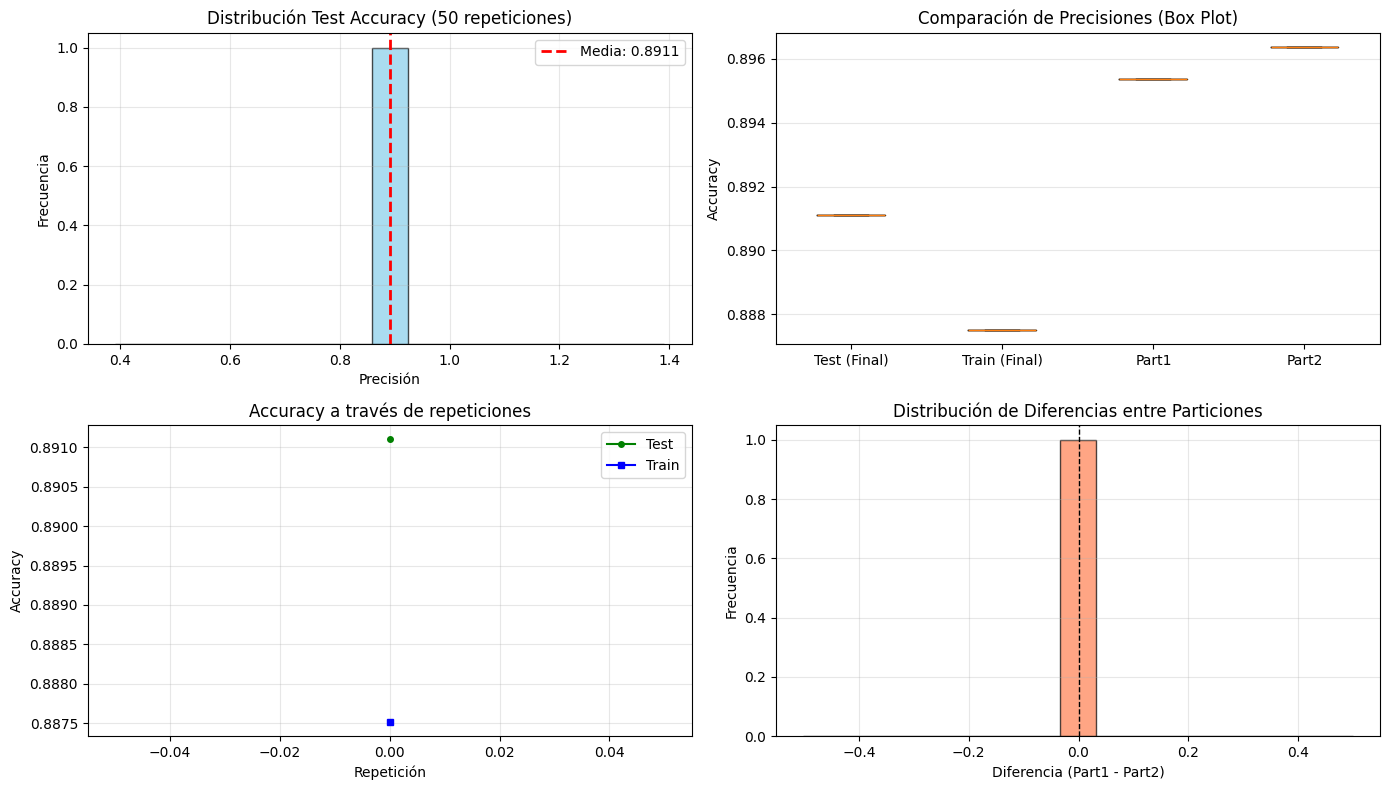

In [51]:
# Visualizar distribución de resultados
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Gráfico 1: Distribución de precisión en test
axes[0, 0].hist(test_acc_arr, bins=15, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(np.mean(test_acc_arr), color='red', linestyle='--', linewidth=2, label=f'Media: {np.mean(test_acc_arr):.4f}')
axes[0, 0].set_xlabel('Precisión')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución Test Accuracy (50 repeticiones)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Gráfico 2: Box plot comparativo
box_data = [test_acc_arr, train_acc_arr, part1_acc_arr, part2_acc_arr]
axes[0, 1].boxplot(box_data, labels=['Test (Final)', 'Train (Final)', 'Part1', 'Part2'])
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Comparación de Precisiones (Box Plot)')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Gráfico 3: Línea de convergencia
axes[1, 0].plot(test_acc_arr, 'o-', color='green', label='Test', markersize=4)
axes[1, 0].plot(train_acc_arr, 's-', color='blue', label='Train', markersize=4)
axes[1, 0].set_xlabel('Repetición')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_title('Accuracy a través de repeticiones')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Gráfico 4: Diferencia entre particiones
diff_particiones = part1_acc_arr - part2_acc_arr
axes[1, 1].hist(diff_particiones, bins=15, color='coral', edgecolor='black', alpha=0.7)
axes[1, 1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1, 1].set_xlabel('Diferencia (Part1 - Part2)')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].set_title('Distribución de Diferencias entre Particiones')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [52]:
def guardar_modelo(ruta="modelo_mnist_promediado.npz"):
    """Guarda el modelo final promediado."""
    np.savez(
        ruta,
        w1_final=params_final['w1'], b1_final=params_final['b1'],
        w2_final=params_final['w2'], b2_final=params_final['b2']
    )
    print(f"Modelo promediado guardado en {ruta}")

def cargar_modelo(ruta="modelo_mnist_promediado.npz"):
    """Carga el modelo final promediado."""
    global params_final

    datos = np.load(ruta)
    params_final = {
        'w1': datos['w1_final'], 'b1': datos['b1_final'],
        'w2': datos['w2_final'], 'b2': datos['b2_final']
    }
    print(f"Modelo promediado cargado desde {ruta}")

# Guardar el modelo promediado
guardar_modelo()

Modelo promediado guardado en modelo_mnist_promediado.npz


In [53]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def cargar_imagen(path: str, invertir=False):
    """Carga y prepara una imagen para inferencia."""
    img = Image.open(path)
    img = img.convert("L")
    img = img.resize((28, 28))

    img_array = np.array(img)
    img_array = img_array / 255.0

    if invertir:
        img_array = 1.0 - img_array

    img_vector = img_array.flatten().reshape(1, -1)
    return img_vector

def mostrar_imagen(vector):
    """Muestra una imagen procesada 28x28."""
    if vector.shape[0] == 1:
        vector = vector.reshape(-1)
    img = vector.reshape(28, 28)
    plt.imshow(img, cmap="gray")
    plt.title("Imagen procesada 28x28")
    plt.axis("off")
    plt.show()

# Cargar modelo promediado
cargar_modelo()

# Inferencia con imagen (reemplazar path con imagen real)
# x = cargar_imagen("ocho.jpg", True)
# mostrar_imagen(x)

# pred_proba = predict_proba(x, params_final)
# pred_clase = np.argmax(pred_proba)[0]

# print("Probabilidades (modelo promediado):", pred_proba)
# print(f"Predicción (modelo promediado): {pred_clase}")

Modelo promediado cargado desde modelo_mnist_promediado.npz
